# Klasifikasi Kondisi Korosi Pipa Industri
## Menggunakan Ekstraksi Fitur GLCM dan Perbandingan Metode KNN, SVM, dan Random Forest
### Percobaan P2: Resize + Grayscale + Histogram Equalization

In [ ]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── corroded
    │   ├── 001.jpg
    │   └── ... (001-121.jpg)
    └── normal
        ├── 001.png
        └── ... (001-120.png)
```

In [3]:
data = []
labels = []
file_name = []
for sub_folder in os.listdir("dataset/"):
    sub_folder_path = os.path.join("dataset/", sub_folder)
    if not os.path.isdir(sub_folder_path):
        continue
    sub_folder_files = os.listdir(sub_folder_path)
    for i, filename in enumerate(sub_folder_files):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            continue
        img_path = os.path.join("dataset/", sub_folder, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data, dtype=object)
labels = np.array(labels)
print("Total data loaded:", len(data))

Total data loaded: 241


## Data Preparation

### Define Preprocessing Function

In [4]:
def resize(image, target_size):
    return cv.resize(image, target_size, interpolation=cv.INTER_AREA)

def toGrayscale(image):
    if len(image.shape) == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return image

def histogramEqualization(image):
    return cv.equalizeHist(image)

def prepro2(image):
    # P2: Resize + Grayscale + Histogram Equalization
    img = resize(image, (128, 128))
    img = toGrayscale(img)
    img = histogramEqualization(img)
    return img

### Preprocessing

In [5]:
dataPreprocessed = []
for i in range(len(data)):
    dataPreprocessed.append(prepro2(data[i]))

dataPreprocessed = np.array(dataPreprocessed)
print("Shape data preprocessed:", dataPreprocessed.shape)

Shape data preprocessed: (241, 128, 128)


### Feature Extraction

In [6]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [7]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

In [8]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

In [9]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

In [10]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

In [11]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

In [12]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

In [13]:
def entropyGlcm(matriks):
    glcm_flat = matriks[:, :, 0, 0].ravel()
    glcm_flat = glcm_flat[glcm_flat > 0]
    return entropy(glcm_flat)

In [14]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [15]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [16]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [17]:
for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [18]:
for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [19]:
for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [20]:
for i in range(len(dataPreprocessed)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [21]:
for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [22]:
for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Write the extraction's results to CSV

In [23]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_P2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_P2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,001.jpg,Corroded,470.402805,758.754418,613.436823,861.467605,0.207456,0.154148,0.232110,0.176019,...,0.000502,0.000418,0.022724,0.019442,0.022399,0.020443,0.956800,0.930238,0.943331,0.920797
1,002.jpg,Corroded,1066.008305,1964.305103,1803.206262,2109.561783,0.108841,0.075682,0.080106,0.067803,...,0.000257,0.000231,0.018334,0.015584,0.016036,0.015202,0.902324,0.819278,0.833794,0.805900
2,003.jpg,Corroded,273.174520,509.405109,419.672490,553.624093,0.152122,0.113338,0.129689,0.106818,...,0.000202,0.000169,0.015362,0.013525,0.014216,0.013018,0.974831,0.953029,0.961241,0.948952
3,004.jpg,Corroded,711.838214,1209.326431,818.545276,1060.392895,0.142781,0.101550,0.123637,0.123392,...,0.000349,0.000317,0.021042,0.017921,0.018692,0.017814,0.934752,0.888898,0.924955,0.902586
4,005.jpg,Corroded,177.708538,363.594519,266.044414,313.065844,0.207479,0.198419,0.205274,0.142374,...,0.000922,0.000693,0.030519,0.029030,0.030360,0.026318,0.983378,0.965936,0.975179,0.970674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,116.png,Normal,522.533095,953.125488,875.742987,1099.195982,0.243560,0.212408,0.267566,0.243788,...,0.000909,0.000806,0.030481,0.026949,0.030146,0.028393,0.951848,0.912384,0.919652,0.898952
237,117.png,Normal,363.716966,997.676855,698.181102,675.000682,0.211673,0.136860,0.184582,0.233240,...,0.000826,0.000921,0.031110,0.025336,0.028734,0.030341,0.966370,0.907774,0.935313,0.937603
238,118.png,Normal,269.094611,638.356129,416.331385,489.355695,0.323697,0.212955,0.270728,0.272218,...,0.001355,0.001166,0.039403,0.032236,0.036808,0.034150,0.975153,0.941197,0.961677,0.954924
239,119.png,Normal,210.568344,570.588505,366.903359,350.074400,0.251802,0.192627,0.187790,0.213429,...,0.000537,0.000561,0.026195,0.021540,0.023164,0.023688,0.980489,0.947194,0.966112,0.967601


### Features Selection

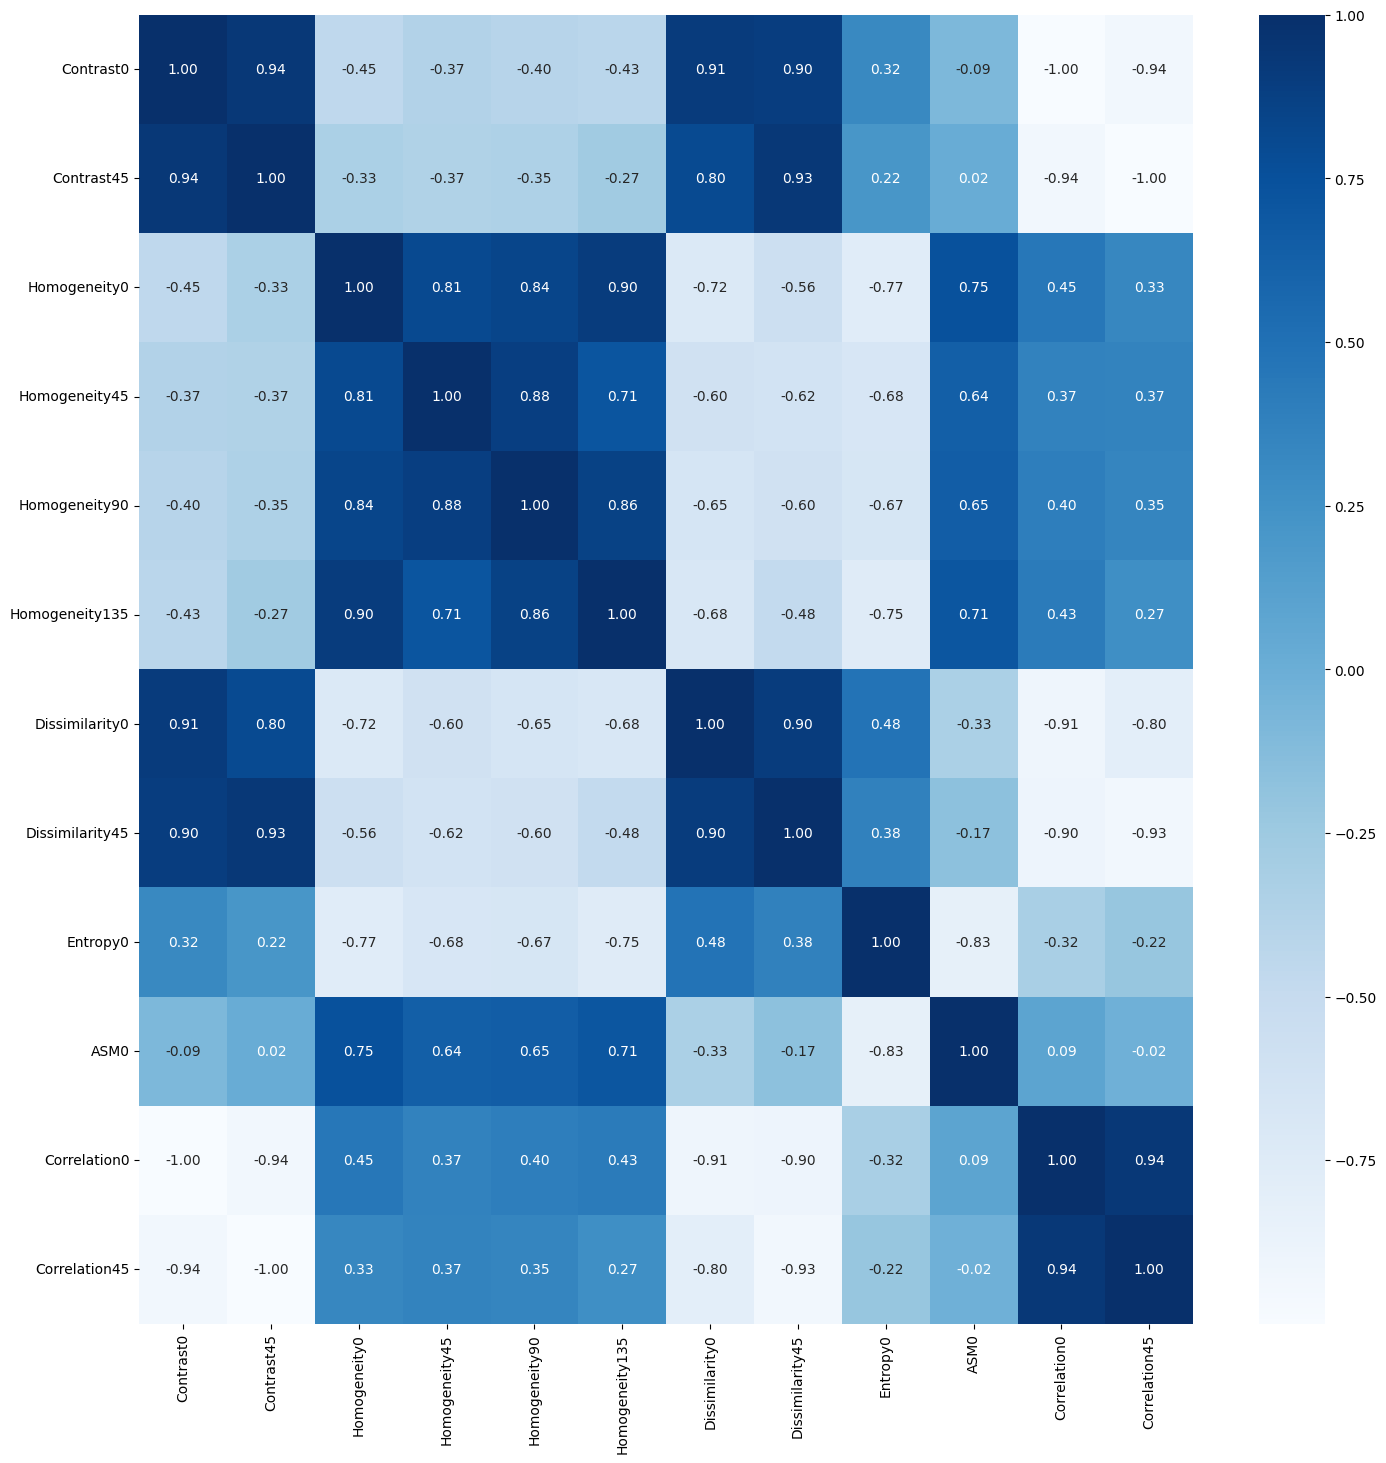

In [24]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
    for j in range(i+1, correlation.shape[0]):
        if correlation.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.show()

## Splitting Data

In [25]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(192, 12)
(49, 12)


## Feature Normalization

In [26]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

### Define Model

In [27]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [28]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred_rf_train = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_rf_train)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred_rf_test = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf_test)

------Training Set------
              precision    recall  f1-score   support

    Corroded       1.00      1.00      1.00        95
      Normal       1.00      1.00      1.00        97

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192

[[95  0]
 [ 0 97]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.76      0.85      0.80        26
      Normal       0.80      0.70      0.74        23

    accuracy                           0.78        49
   macro avg       0.78      0.77      0.77        49
weighted avg       0.78      0.78      0.77        49

[[22  4]
 [ 7 16]]
Accuracy: 0.7755102040816326


### Train SVM Classifier

In [29]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred_svm_train = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_svm_train)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred_svm_test = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm_test)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.97      0.89      0.93        95
      Normal       0.90      0.97      0.94        97

    accuracy                           0.93       192
   macro avg       0.93      0.93      0.93       192
weighted avg       0.93      0.93      0.93       192

[[85 10]
 [ 3 94]]
Accuracy: 0.9322916666666666

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.87      0.77      0.82        26
      Normal       0.77      0.87      0.82        23

    accuracy                           0.82        49
   macro avg       0.82      0.82      0.82        49
weighted avg       0.82      0.82      0.82        49

[[20  6]
 [ 3 20]]
Accuracy: 0.8163265306122449


### Train KNN Classifier

In [30]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred_knn_train = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_knn_train)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred_knn_test = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn_test)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.94      0.94      0.94        95
      Normal       0.94      0.94      0.94        97

    accuracy                           0.94       192
   macro avg       0.94      0.94      0.94       192
weighted avg       0.94      0.94      0.94       192

[[89  6]
 [ 6 91]]
Accuracy: 0.9375

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.75      0.81      0.78        26
      Normal       0.76      0.70      0.73        23

    accuracy                           0.76        49
   macro avg       0.76      0.75      0.75        49
weighted avg       0.76      0.76      0.75        49

[[21  5]
 [ 7 16]]
Accuracy: 0.7551020408163265


## Evaluation With Confusion Matrix

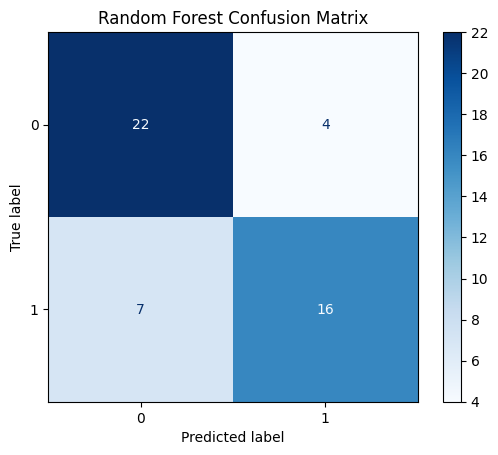

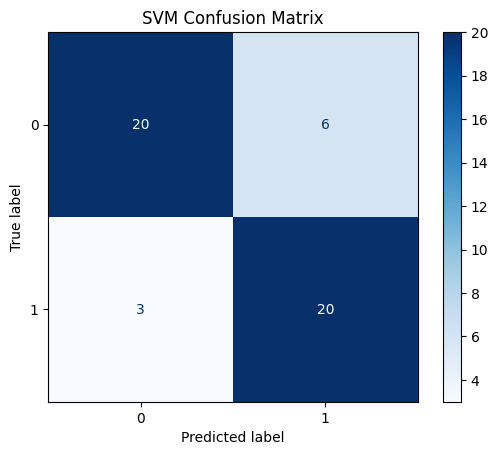

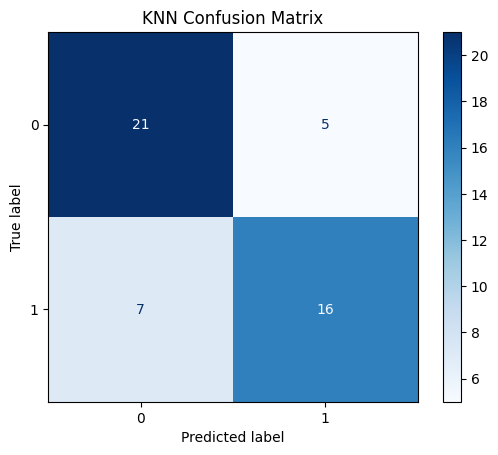

In [31]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, y_pred_rf_test, "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, y_pred_svm_test, "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, y_pred_knn_test, "KNN Confusion Matrix")